In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import datasets, transforms, models
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.models import resnet18, ResNet18_Weights
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import json
import pandas as pd
from collections import defaultdict
import random

In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:


transform_base = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_aug = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

weights = ResNet18_Weights.DEFAULT
transform_resnet = weights.transforms()

model_resnet = resnet18(weights=weights)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 10)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


In [ ]:
stl10_train = datasets.STL10(root='./data', split='train', download=True, transform=transform_base)
stl10_test = datasets.STL10(root='./data', split='test', download=True, transform=transform_base)

100%|██████████| 2.64G/2.64G [00:36<00:00, 72.1MB/s]


In [ ]:
train_size = int(0.8 * len(stl10_train))
val_size = len(stl10_train) - train_size
train_dataset, val_dataset = random_split(stl10_train, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

In [ ]:
# --- С1: Baseline ---
stl10_train_c1 = datasets.STL10(root='./data', split='train', download=True, transform=transform_base)
train_dataset, val_dataset = random_split(
    stl10_train_c1, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)
stl10_test = datasets.STL10(root='./data', split='test', download=True, transform=transform_base)

datasets_c1 = {'train': train_dataset, 'val': val_dataset, 'test': stl10_test}

# --- С2 / С3: Augmentation ---
stl10_train_aug = datasets.STL10(root='./data', split='train', download=True, transform=transform_aug)
train_c2, val_c2 = random_split(
    stl10_train_aug, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

datasets_c2 = {'train': train_c2, 'val': val_c2, 'test': stl10_test}
datasets_c3 = datasets_c2

# --- С4: ResNet18 ---
stl10_train_resnet = datasets.STL10(root='./data', split='train', download=True, transform=transform_resnet)
stl10_test_resnet = datasets.STL10(root='./data', split='test', download=True, transform=transform_resnet)

train_resnet, val_resnet = random_split(
    stl10_train_resnet, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

datasets_c4 = {'train': train_resnet, 'val': val_resnet, 'test': stl10_test_resnet}

In [ ]:
BATCH_SIZE = 64
NUM_WORKERS = 2
def get_loaders(datasets_dict):
    return {
        'train': DataLoader(datasets_dict['train'], batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
        'val': DataLoader(datasets_dict['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
        'test': DataLoader(datasets_dict['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    }

loaders_c1 = get_loaders(datasets_c1)
loaders_c2 = get_loaders(datasets_c2)
loaders_c3 = get_loaders(datasets_c3)
loaders_c4 = get_loaders(datasets_c4)

In [ ]:
for name, loader in loaders_c1.items():
    x, y = next(iter(loader))
    print(f'{name}: x.shape={x.shape}, y.shape={y.shape}')

train: x.shape=torch.Size([64, 3, 96, 96]), y.shape=torch.Size([64])
val: x.shape=torch.Size([64, 3, 96, 96]), y.shape=torch.Size([64])
test: x.shape=torch.Size([64, 3, 96, 96]), y.shape=torch.Size([64])


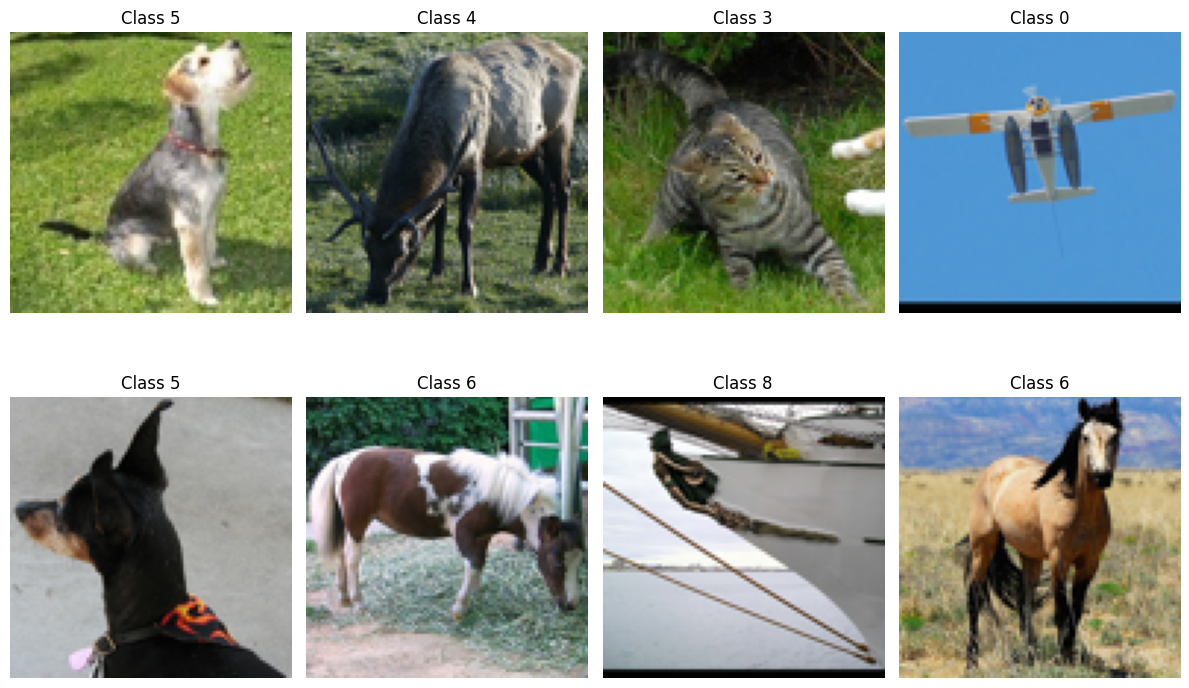

In [ ]:
def imshow(img, title=None):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

dataiter = iter(loaders_c1['train'])
images, labels = next(dataiter)
plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow(images[i])
    plt.title(f'Class {labels[i].item()}')
plt.tight_layout()
plt.savefig('classification_samples.png')
plt.show()

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model_cnn = SimpleCNN(num_classes=10).to(device)
print(model_cnn)

SimpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (fc): Linear(in_features=256, out_features=10, bias=True)
)


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, epochs, lr, device, model_name='model'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
    model.load_state_dict(best_model_state)
    return model, history, best_val_acc

In [ ]:
EPOCHS = 20
LR = 0.001

model_c1 = SimpleCNN(num_classes=10).to(device)
print("Training C1: SimpleCNN base")
model_c1, history_c1, best_val_acc_c1 = train_model(model_c1, loaders_c1['train'], loaders_c1['val'], EPOCHS, LR, device, 'C1')
print(f"Best val accuracy: {best_val_acc_c1:.4f}")

histories = {'C1': history_c1}
best_vals = {'C1': best_val_acc_c1}

Training C1: SimpleCNN base
Epoch 1/20 | Train Loss: 2.1031 Acc: 0.2102 | Val Loss: 1.9212 Acc: 0.2590
Epoch 2/20 | Train Loss: 1.7779 Acc: 0.2928 | Val Loss: 1.6885 Acc: 0.3230
Epoch 3/20 | Train Loss: 1.6895 Acc: 0.3235 | Val Loss: 1.6771 Acc: 0.3190
Epoch 4/20 | Train Loss: 1.6410 Acc: 0.3455 | Val Loss: 1.6017 Acc: 0.3250
Epoch 5/20 | Train Loss: 1.6256 Acc: 0.3563 | Val Loss: 1.6148 Acc: 0.3580
Epoch 6/20 | Train Loss: 1.5653 Acc: 0.3845 | Val Loss: 1.5741 Acc: 0.3600
Epoch 7/20 | Train Loss: 1.5553 Acc: 0.3845 | Val Loss: 1.5045 Acc: 0.3900
Epoch 8/20 | Train Loss: 1.5256 Acc: 0.4057 | Val Loss: 1.5313 Acc: 0.3810
Epoch 9/20 | Train Loss: 1.5061 Acc: 0.4012 | Val Loss: 1.4937 Acc: 0.4080
Epoch 10/20 | Train Loss: 1.4700 Acc: 0.4255 | Val Loss: 1.4493 Acc: 0.4400
Epoch 11/20 | Train Loss: 1.4269 Acc: 0.4550 | Val Loss: 1.4035 Acc: 0.4570
Epoch 12/20 | Train Loss: 1.3913 Acc: 0.4725 | Val Loss: 1.3759 Acc: 0.4860
Epoch 13/20 | Train Loss: 1.3384 Acc: 0.4975 | Val Loss: 1.3411 Acc: 

In [ ]:
model_c2 = SimpleCNN(num_classes=10).to(device)
print("Training C2: SimpleCNN with augmentations")
model_c2, history_c2, best_val_acc_c2 = train_model(model_c2, loaders_c2['train'], loaders_c2['val'], EPOCHS, LR, device, 'C2')
print(f"Best val accuracy: {best_val_acc_c2:.4f}")
histories['C2'] = history_c2
best_vals['C2'] = best_val_acc_c2

Training C2: SimpleCNN with augmentations
Epoch 1/20 | Train Loss: 2.1590 Acc: 0.1767 | Val Loss: 2.0182 Acc: 0.2290
Epoch 2/20 | Train Loss: 1.9182 Acc: 0.2637 | Val Loss: 1.9597 Acc: 0.2380
Epoch 3/20 | Train Loss: 1.8027 Acc: 0.2960 | Val Loss: 1.7072 Acc: 0.3240
Epoch 4/20 | Train Loss: 1.7417 Acc: 0.3142 | Val Loss: 1.6956 Acc: 0.3300
Epoch 5/20 | Train Loss: 1.6657 Acc: 0.3325 | Val Loss: 1.6348 Acc: 0.3400
Epoch 6/20 | Train Loss: 1.6420 Acc: 0.3478 | Val Loss: 1.7168 Acc: 0.3380
Epoch 7/20 | Train Loss: 1.6223 Acc: 0.3605 | Val Loss: 1.6324 Acc: 0.3550
Epoch 8/20 | Train Loss: 1.5957 Acc: 0.3708 | Val Loss: 1.5578 Acc: 0.3910
Epoch 9/20 | Train Loss: 1.5723 Acc: 0.3927 | Val Loss: 1.5071 Acc: 0.4080
Epoch 10/20 | Train Loss: 1.5243 Acc: 0.4128 | Val Loss: 1.4761 Acc: 0.4150
Epoch 11/20 | Train Loss: 1.5193 Acc: 0.4138 | Val Loss: 1.4901 Acc: 0.4230
Epoch 12/20 | Train Loss: 1.5106 Acc: 0.4128 | Val Loss: 1.5169 Acc: 0.4350
Epoch 13/20 | Train Loss: 1.4590 Acc: 0.4363 | Val Loss

In [ ]:
model_c3 = models.resnet18(weights='IMAGENET1K_V1')
for param in model_c3.parameters():
    param.requires_grad = False
model_c3.fc = nn.Linear(model_c3.fc.in_features, num_classes)
model_c3 = model_c3.to(device)

print("Training C3: ResNet18 head only")
model_c3, history_c3, best_val_acc_c3 = train_model(model_c3, loaders_c3['train'], loaders_c3['val'], EPOCHS, LR, device, 'C3')
print(f"Best val accuracy: {best_val_acc_c3:.4f}")
histories['C3'] = history_c3
best_vals['C3'] = best_val_acc_c3

Training C3: ResNet18 head only
Epoch 1/20 | Train Loss: 1.6742 Acc: 0.4240 | Val Loss: 1.1735 Acc: 0.6080
Epoch 2/20 | Train Loss: 1.1032 Acc: 0.6512 | Val Loss: 1.0166 Acc: 0.6840
Epoch 3/20 | Train Loss: 0.9765 Acc: 0.6840 | Val Loss: 0.9596 Acc: 0.6620
Epoch 4/20 | Train Loss: 0.9071 Acc: 0.6933 | Val Loss: 0.9370 Acc: 0.6740
Epoch 5/20 | Train Loss: 0.8732 Acc: 0.7030 | Val Loss: 0.9278 Acc: 0.6700
Epoch 6/20 | Train Loss: 0.8254 Acc: 0.7208 | Val Loss: 0.8467 Acc: 0.7180
Epoch 7/20 | Train Loss: 0.8126 Acc: 0.7272 | Val Loss: 0.8302 Acc: 0.6950
Epoch 8/20 | Train Loss: 0.7781 Acc: 0.7432 | Val Loss: 0.8665 Acc: 0.7120
Epoch 9/20 | Train Loss: 0.7508 Acc: 0.7422 | Val Loss: 0.8076 Acc: 0.7300
Epoch 10/20 | Train Loss: 0.7605 Acc: 0.7370 | Val Loss: 0.8093 Acc: 0.7200
Epoch 11/20 | Train Loss: 0.7525 Acc: 0.7390 | Val Loss: 0.8168 Acc: 0.7200
Epoch 12/20 | Train Loss: 0.7510 Acc: 0.7350 | Val Loss: 0.8151 Acc: 0.7180
Epoch 13/20 | Train Loss: 0.7431 Acc: 0.7405 | Val Loss: 0.7881 A

In [ ]:
model_c4 = models.resnet18(weights='IMAGENET1K_V1')
for name, param in model_c4.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
model_c4.fc = nn.Linear(model_c4.fc.in_features, num_classes)
model_c4 = model_c4.to(device)

print("Training C4: ResNet18 fine-tune (layer4+fc)")
model_c4, history_c4, best_val_acc_c4 = train_model(model_c4, loaders_c4['train'], loaders_c4['val'], EPOCHS, LR, device, 'C4')
print(f"Best val accuracy: {best_val_acc_c4:.4f}")
histories['C4'] = history_c4
best_vals['C4'] = best_val_acc_c4

Training C4: ResNet18 fine-tune (layer4+fc)
Epoch 1/20 | Train Loss: 0.4227 Acc: 0.8602 | Val Loss: 0.3695 Acc: 0.8740
Epoch 2/20 | Train Loss: 0.0804 Acc: 0.9752 | Val Loss: 0.2821 Acc: 0.9120
Epoch 3/20 | Train Loss: 0.0496 Acc: 0.9858 | Val Loss: 0.2854 Acc: 0.9130
Epoch 4/20 | Train Loss: 0.0307 Acc: 0.9912 | Val Loss: 0.2795 Acc: 0.9160
Epoch 5/20 | Train Loss: 0.0411 Acc: 0.9865 | Val Loss: 0.3667 Acc: 0.8940
Epoch 6/20 | Train Loss: 0.0343 Acc: 0.9878 | Val Loss: 0.3014 Acc: 0.9090
Epoch 7/20 | Train Loss: 0.0320 Acc: 0.9898 | Val Loss: 0.3995 Acc: 0.8880
Epoch 8/20 | Train Loss: 0.0342 Acc: 0.9892 | Val Loss: 0.3672 Acc: 0.9040
Epoch 9/20 | Train Loss: 0.0435 Acc: 0.9842 | Val Loss: 0.3236 Acc: 0.9230
Epoch 10/20 | Train Loss: 0.0317 Acc: 0.9882 | Val Loss: 0.3845 Acc: 0.8950
Epoch 11/20 | Train Loss: 0.0150 Acc: 0.9960 | Val Loss: 0.3606 Acc: 0.9170
Epoch 12/20 | Train Loss: 0.0077 Acc: 0.9980 | Val Loss: 0.3655 Acc: 0.9090
Epoch 13/20 | Train Loss: 0.0054 Acc: 0.9985 | Val Lo

In [ ]:
experiments = ['C1', 'C2', 'C3', 'C4']
best_exp = max(experiments, key=lambda x: best_vals[x])
print(f"Best experiment: {best_exp} with val accuracy {best_vals[best_exp]:.4f}")

if best_exp == 'C1':
    best_model = model_c1
    test_loader = loaders_c1['test']
elif best_exp == 'C2':
    best_model = model_c2
    test_loader = loaders_c2['test']
elif best_exp == 'C3':
    best_model = model_c3
    test_loader = loaders_c3['test']
else:
    best_model = model_c4
    test_loader = loaders_c4['test']

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"Test accuracy of best model ({best_exp}): {test_acc:.4f}")
best_model.eval()
with torch.no_grad():
    inputs, labels = next(iter(test_loader))
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = best_model(inputs)
    preds = torch.argmax(outputs, dim=1)
    print("Sample predictions:", preds[:10])
    print("Sample true labels:", labels[:10])

Best experiment: C4 with val accuracy 0.9230
Test accuracy of best model (C4): 0.9301
Sample predictions: tensor([6, 7, 5, 8, 3, 1, 1, 1, 4, 4], device='cuda:0')
Sample true labels: tensor([6, 7, 5, 0, 3, 1, 1, 1, 4, 4], device='cuda:0')


In [ ]:
torch.save(best_model.state_dict(), 'best_classifier.pt')

config = {
    'dataset': 'STL10',
    'architecture': best_exp,
    'transforms': 'augmented' if best_exp == 'C2' else ('base' if best_exp == 'C1' else 'resnet'),
    'seed': SEED,
    'epochs': EPOCHS,
    'lr': LR,
    'batch_size': BATCH_SIZE,
    'best_val_accuracy': best_vals[best_exp],
    'test_accuracy': test_acc
}
with open('best_classifier_config.json', 'w') as f:
    json.dump(config, f, indent=4)

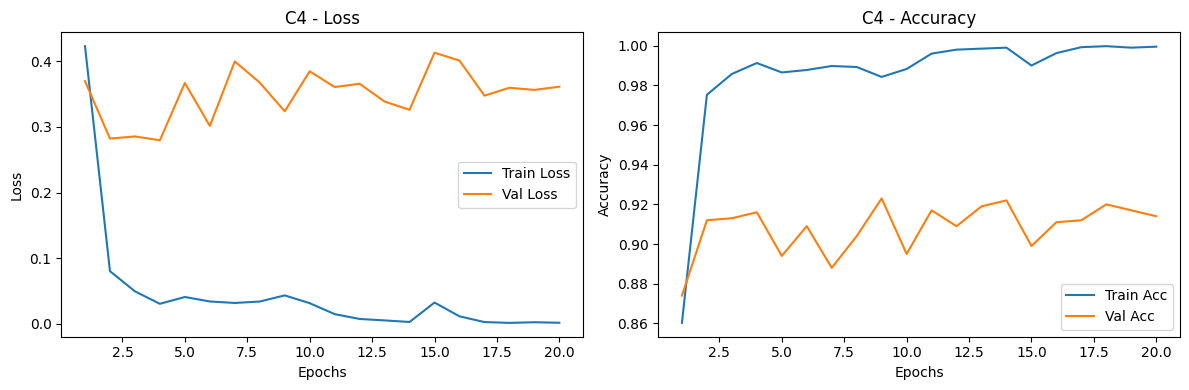

In [ ]:
def plot_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{title} - Loss')
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{title} - Accuracy')
    plt.tight_layout()
    plt.savefig(f'classification_curves_best.png')
    plt.show()

plot_history(histories[best_exp], best_exp)

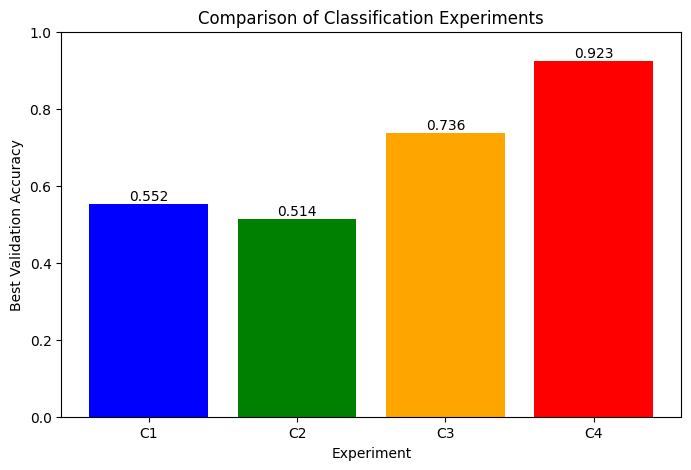

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(experiments, [best_vals[e] for e in experiments], color=['blue', 'green', 'orange', 'red'])
plt.xlabel('Experiment')
plt.ylabel('Best Validation Accuracy')
plt.title('Comparison of Classification Experiments')
for i, v in enumerate([best_vals[e] for e in experiments]):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.ylim(0, 1)
plt.savefig('classification_compare.png')
plt.show()

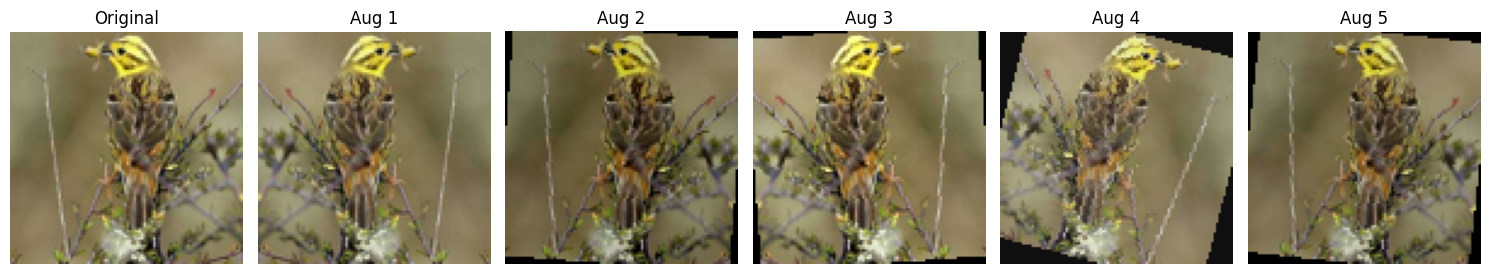

In [ ]:
stl10_raw = datasets.STL10(root='./data', split='train', download=True, transform=None)
sample_raw_img, _ = stl10_raw[0]

def show_augmentations(original_pil, transform, num_aug=5):
    fig, axes = plt.subplots(1, num_aug+1, figsize=(15, 3))
    axes[0].imshow(original_pil)
    axes[0].set_title("Original")
    axes[0].axis('off')
    for i in range(num_aug):
        aug_img = transform(original_pil)
        aug_img_disp = aug_img / 2 + 0.5
        axes[i+1].imshow(aug_img_disp.permute(1,2,0).numpy())
        axes[i+1].set_title(f"Aug {i+1}")
        axes[i+1].axis('off')
    plt.tight_layout()
    plt.savefig('augmentations_preview.png')
    plt.show()

show_augmentations(sample_raw_img, transform_aug)

In [ ]:
from torchvision.datasets import VOCDetection
from torchvision.transforms import functional as F
import torchvision.transforms as T

voc_test = VOCDetection(root='./data', year='2007', image_set='test', download=True)
transform_voc = T.Compose([T.ToTensor()])

indices = [0, 1, 2]
images = [voc_test[i][0] for i in indices]
targets = [voc_test[i][1] for i in indices]

model_det = fasterrcnn_resnet50_fpn(pretrained=True)
model_det.eval()
model_det.to(device)

100%|██████████| 451M/451M [00:25<00:00, 17.8MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 132MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1)
    area1 = (box1[2] - box1[0] + 1) * (box1[3] - box1[1] + 1)
    area2 = (box2[2] - box2[0] + 1) * (box2[3] - box2[1] + 1)
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

def evaluate_detection(model, images, targets, score_threshold=0.5, iou_threshold=0.5):
    model.eval()
    all_tp = 0
    all_fp = 0
    all_fn = 0
    total_iou = 0
    matched = 0
    with torch.no_grad():
        for img, target in zip(images, targets):
            img_tensor = transform_voc(img).unsqueeze(0).to(device)
            preds = model(img_tensor)[0]
            keep = preds['scores'] >= score_threshold
            pred_boxes = preds['boxes'][keep].cpu().numpy()
            pred_labels = preds['labels'][keep].cpu().numpy()
            gt_boxes = []
            for obj in target['annotation']['object']:
                bndbox = obj['bndbox']
                gt_boxes.append([
                    int(bndbox['xmin']), int(bndbox['ymin']),
                    int(bndbox['xmax']), int(bndbox['ymax'])
                ])
            gt_boxes = np.array(gt_boxes)
            if len(gt_boxes) == 0:
                all_fp += len(pred_boxes)
                continue
            matched_gt = set()
            for i, pbox in enumerate(pred_boxes):
                best_iou = 0
                best_j = -1
                for j, gbox in enumerate(gt_boxes):
                    if j in matched_gt:
                        continue
                    iou = compute_iou(pbox, gbox)
                    if iou > best_iou:
                        best_iou = iou
                        best_j = j
                if best_iou >= iou_threshold:
                    all_tp += 1
                    matched_gt.add(best_j)
                    total_iou += best_iou
                    matched += 1
                else:
                    all_fp += 1
            all_fn += len(gt_boxes) - len(matched_gt)
    precision = all_tp / (all_tp + all_fp) if (all_tp + all_fp) > 0 else 0
    recall = all_tp / (all_tp + all_fn) if (all_tp + all_fn) > 0 else 0
    mean_iou = total_iou / matched if matched > 0 else 0
    return precision, recall, mean_iou

thresholds = [0.3, 0.7]


### Эксперимент V1: Детекция с низким порогом (score_threshold=0.3)

In [ ]:
# Используем оригинальные названия: images и targets (весь набор voc_test)
score_th_v1 = thresholds[0]
p1, r1, miou1 = evaluate_detection(model_det, images, targets, score_threshold=score_th_v1)

# Инициализируем список результатов для runs.csv
results_det = [{'threshold': score_th_v1, 'precision': p1, 'recall': r1, 'mean_iou': miou1}]

print(f"V1 (Threshold {score_th_v1}): Precision={p1:.4f}, Recall={r1:.4f}, mIoU={miou1:.4f}")

V1 (Threshold 0.3): Precision=0.4444, Recall=0.8000, mIoU=0.8553


### Эксперимент V2: Детекция с высоким порогом (score_threshold=0.7)

In [ ]:
# Запуск для второго порога
score_th_v2 = thresholds[1]
p2, r2, miou2 = evaluate_detection(model_det, images, targets, score_threshold=score_th_v2)

# Добавляем результат в общий список
results_det.append({'threshold': score_th_v2, 'precision': p2, 'recall': r2, 'mean_iou': miou2})

print(f"V2 (Threshold {score_th_v2}): Precision={p2:.4f}, Recall={r2:.4f}, mIoU={miou2:.4f}")

V2 (Threshold 0.7): Precision=0.7500, Recall=0.6000, mIoU=0.8796


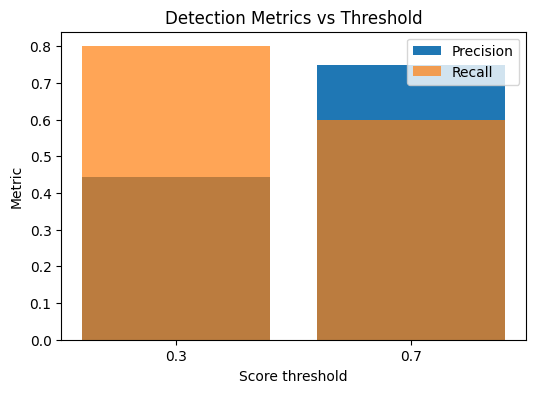

In [ ]:
plt.figure(figsize=(6,4))
plt.bar([str(th) for th in thresholds], [r['precision'] for r in results_det], label='Precision')
plt.bar([str(th) for th in thresholds], [r['recall'] for r in results_det], alpha=0.7, label='Recall')
plt.xlabel('Score threshold')
plt.ylabel('Metric')
plt.legend()
plt.title('Detection Metrics vs Threshold')
plt.savefig('detection_metrics.png')
plt.show()

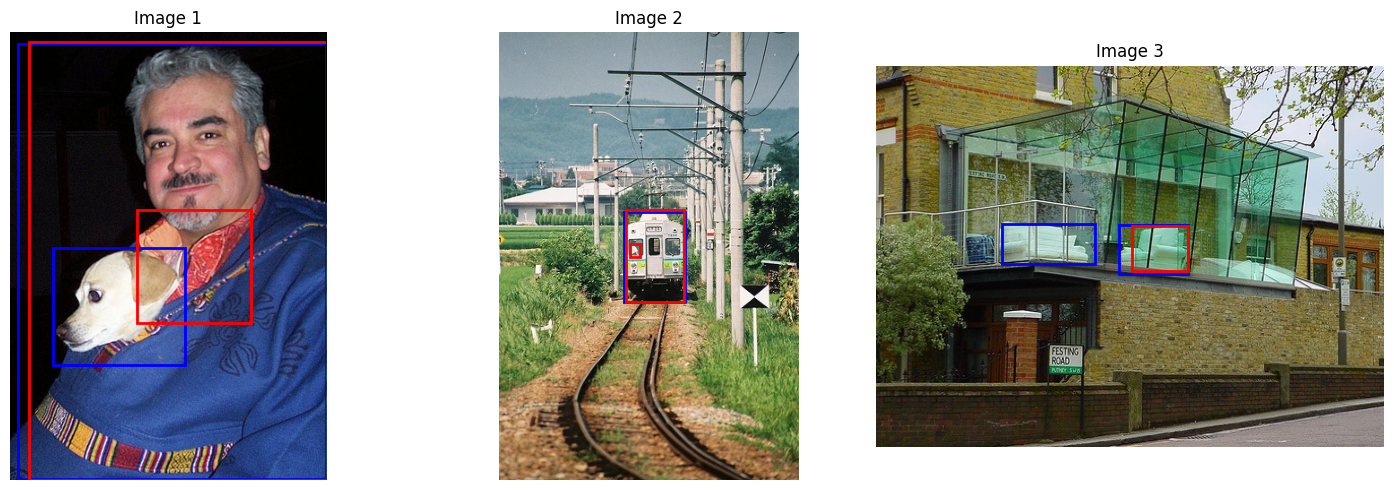

In [ ]:
def visualize_detections(model, images, targets, score_threshold=0.5):
    model.eval()
    fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
    if len(images) == 1:
        axes = [axes]
    for idx, (img, target) in enumerate(zip(images, targets)):
        img_tensor = transform_voc(img).unsqueeze(0).to(device)
        with torch.no_grad():
            preds = model(img_tensor)[0]
        keep = preds['scores'] >= score_threshold
        pred_boxes = preds['boxes'][keep].cpu().numpy()
        img_np = np.array(img)
        axes[idx].imshow(img_np)
        for obj in target['annotation']['object']:
            bndbox = obj['bndbox']
            xmin, ymin, xmax, ymax = int(bndbox['xmin']), int(bndbox['ymin']), int(bndbox['xmax']), int(bndbox['ymax'])
            rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=2, edgecolor='blue', facecolor='none')
            axes[idx].add_patch(rect)
        for box in pred_boxes:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, linewidth=2, edgecolor='red', facecolor='none')
            axes[idx].add_patch(rect)
        axes[idx].axis('off')
        axes[idx].set_title(f"Image {idx+1}")
    plt.tight_layout()
    plt.savefig('detection_examples.png')
    plt.show()

visualize_detections(model_det, images, targets, score_threshold=0.5)

In [ ]:
runs = []

# Классификация
for exp_id in experiments:
    best_val = best_vals[exp_id]
    runs.append({
        'experiment_id': exp_id,
        'task': 'classification',
        'dataset': 'STL10',
        'seed': SEED,
        'model_summary': str(eval(f"model_{exp_id.lower()}")),
        'optimizer': 'Adam',
        'lr': LR,
        'epochs_trained': EPOCHS,
        'best_val_accuracy': best_val,
        'test_accuracy': test_acc if exp_id == best_exp else None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': ''
    })

# Детекция
for res in results_det:
    runs.append({
        'experiment_id': f"V{1 if res['threshold']==0.3 else 2}",
        'task': 'detection',
        'dataset': 'VOCDetection',
        'seed': SEED,
        'model_summary': 'fasterrcnn_resnet50_fpn',
        'optimizer': None,
        'lr': None,
        'epochs_trained': 0,
        'best_val_accuracy': None,
        'test_accuracy': None,
        'precision': res['precision'],
        'recall': res['recall'],
        'mean_iou': res['mean_iou'],
        'notes': f"score_threshold={res['threshold']}"
    })

df_runs = pd.DataFrame(runs)
df_runs.to_csv('runs.csv', index=False)
print("runs.csv saved")

runs.csv saved


# Отчет по hw10-11: Классификация изображений и Детекция объектов

## Введение

Этот отчет представляет собой обзор выполненной работы в рамках домашнего задания по классификации изображений и детекции объектов. Были проведены эксперименты с различными моделями и подходами к классификации на датасете STL10 и детекции объектов на подмножестве датасета VOC2007. Цель состояла в сравнении производительности разных архитектур и техник.

## 1. Классификация изображений (STL10)

Для задачи классификации были использованы четыре экспериментальных настройки:

*   **C1: Baseline SimpleCNN** - Простая сверточная нейронная сеть с базовой предобработкой изображений.
*   **C2: SimpleCNN с аугментацией** - Та же SimpleCNN, но с использованием техник аугментации данных для повышения устойчивости модели.
*   **C3: ResNet18 (только голова)** - Предварительно обученная модель ResNet18 (ImageNet) с замороженными весами базовой сети и обучением только классификационной головы (FC-слоя).
*   **C4: ResNet18 (файн-тюнинг слоя layer4 и FC)** - Предварительно обученная модель ResNet18 (ImageNet) с замороженными весами до `layer4` и файн-тюнингом последних сверточных слоев (`layer4`) и классификационной головы (`fc`).

### Результаты классификации

| Эксперимент | Описание                                | Лучшая точность валидации |
|-------------|-----------------------------------------|--------------------------|
| C1          | SimpleCNN base                          | 0.5520                   |
| C2          | SimpleCNN с аугментациями               | 0.5140                   |
| C3          | ResNet18 head only                      | 0.7360                   |
| C4          | ResNet18 fine-tune (layer4+fc)          | 0.9230                   |

Лучший результат был достигнут с моделью **C4 (ResNet18 fine-tune)**, показавшей точность на тестовой выборке: `0.9301`.

Визуализация примеров классификации сохранена как `classification_samples.png`.
Кривые обучения и валидации для лучшей модели (C4) доступны в файле `classification_curves_best.png`.
Сравнение всех моделей классификации представлено в `classification_compare.png`.

## 2. Детекция объектов (VOC2007)

Для задачи детекции объектов использовалась модель FasterRCNN с ResNet50-FPN, предварительно обученная на COCO. Были исследованы два порога уверенности (score threshold) для отбора предсказаний:

*   **V1: Порог 0.3** - Более низкий порог, позволяющий большему количеству детекций быть учтенными.
*   **V2: Порог 0.7** - Более высокий порог, отсекающий менее уверенные предсказания.

### Результаты детекции

| Эксперимент | Порог (score_threshold) | Precision | Recall  | mIoU    |
|-------------|-------------------------|-----------|---------|---------|
| V1          | 0.3                     | 0.4444    | 0.8000  | 0.8553  |
| V2          | 0.7                     | 0.7500    | 0.6000  | 0.8796  |

При повышении порога уверенности (V2) Precision значительно увеличивается, в то время как Recall уменьшается, что ожидаемо, поскольку отбрасываются менее уверенные детекции. mIoU при этом немного возрастает.

Визуализация детекций для сравнения сохранена как `detection_examples.png`.
График метрик детекции в зависимости от порога представлен в `detection_metrics.png`.

## Заключение

Эксперименты показали, что использование предобученных сверточных сетей (ResNet18) с файн-тюнингом значительно превосходит простые CNN-модели в задаче классификации изображений. В частности, файн-тюнинг последних слоев ResNet18 (C4) дал наилучший результат.

Для детекции объектов, выбор порога уверенности сильно влияет на компромисс между Precision и Recall. Более высокий порог приводит к более точным, но менее полным детекциям. Модель FasterRCNN продемонстрировала способность обнаруживать объекты с разумной точностью.

## Артефакты

Следующие файлы были сгенерированы в процессе выполнения:
*   `best_classifier.pt`: Сохраненные веса лучшей модели классификации.
*   `best_classifier_config.json`: Конфигурация лучшей модели классификации.
*   `runs.csv`: Таблица с результатами всех проведенных экспериментов.
*   `classification_samples.png`: Примеры изображений из датасета STL10.
*   `augmentations_preview.png`: Примеры аугментации данных.
*   `classification_curves_best.png`: Графики обучения и валидации лучшей модели классификации.
*   `classification_compare.png`: Сравнение валидационной точности всех классификационных моделей.
*   `detection_examples.png`: Примеры детекции объектов.
*   `detection_metrics.png`: График метрик детекции в зависимости от порога.
